In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings

In [2]:

df = pd.read_csv("../../integrated/data/total/features_before_selection(6).csv")
print(df.shape)
df.head(10)


(14384, 36)


,conv_id,turn_id,label,toxicity_score,threat_score,topic_drift_score,drift_acceleration,origin_drift,drift_momentum,persistent_drift_count,...,threat_diff,toxicity_accel,threat_accel,risk_slope_3,max_toxicity_so_far,max_threat_so_far,mean_risk_so_far,early_high_risk,late_risk_increase,risk_growth_ratio
0,0,0,0,0.001445,0.007883,0.0000,0.0000,0.0000,0.0000,0,...,0.000000,0.000000,0.000000,0.000000,0.001445,0.007883,0.020276,0.020276,0.002860,-0.858921
1,0,1,0,0.000743,0.001306,0.3763,0.0000,0.3763,0.0000,1,...,-0.006578,-0.000702,-0.006578,-0.015421,0.001445,0.007883,0.012566,0.020276,0.002860,-0.858921
2,0,2,0,0.000129,0.000018,0.3800,0.0037,0.6051,0.3781,2,...,-0.001287,0.000088,0.005290,-0.009928,0.001445,0.007883,0.008517,0.020276,0.002860,-0.858921
3,0,3,0,0.000419,0.000070,0.3180,0.0620,0.7112,0.3581,3,...,0.000052,0.000904,0.001339,-0.006296,0.001445,0.007883,0.006735,0.020276,0.002860,-0.858921
4,0,4,0,0.001484,0.000051,0.4204,0.1024,0.6829,0.3728,4,...,-0.000019,0.000775,-0.000071,-0.000114,0.001484,0.007883,0.006291,0.020276,0.002860,-0.858921
5,0,5,0,0.000872,0.000042,0.4134,0.0070,0.6573,0.3839,5,...,-0.000009,-0.001677,0.000010,0.000752,0.001484,0.007883,0.005689,0.020276,0.002860,-0.858921
6,1,0,0,0.001812,0.018985,0.0000,0.0000,0.0000,0.0000,0,...,0.000000,0.000000,0.000000,0.000000,0.001812,0.018985,0.043872,0.043872,0.036722,-0.162962
7,1,1,0,0.000306,0.016065,0.3287,0.0000,0.3287,0.0000,1,...,-0.002920,-0.001506,-0.002920,-0.010396,0.001812,0.018985,0.038674,0.043872,0.036722,-0.162962
8,1,2,0,0.003349,0.006419,0.4027,0.0739,0.3425,0.3657,2,...,-0.009646,0.004548,-0.006726,-0.010452,0.003349,0.018985,0.033439,0.043872,0.036722,-0.162962
9,1,3,0,0.000609,0.025608,0.3175,0.0852,0.2981,0.3496,3,...,0.019189,-0.005782,0.028835,0.003283,0.003349,0.025608,0.038510,0.043872,0.036722,-0.162962


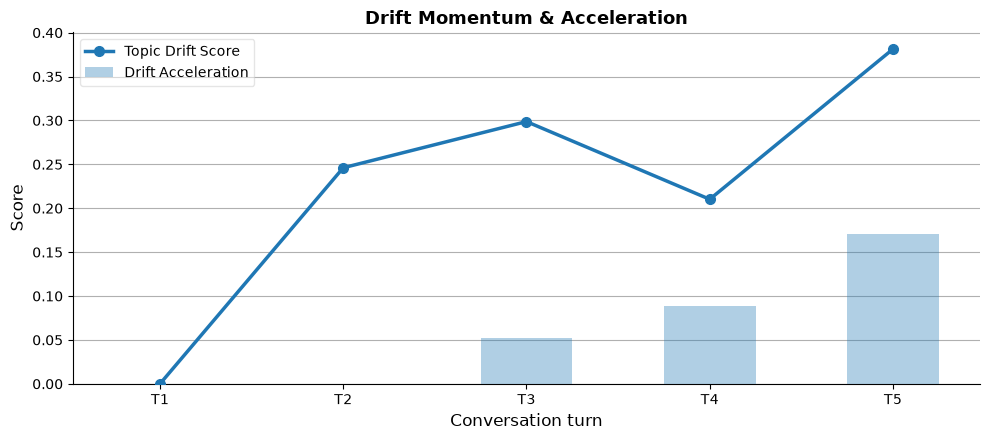

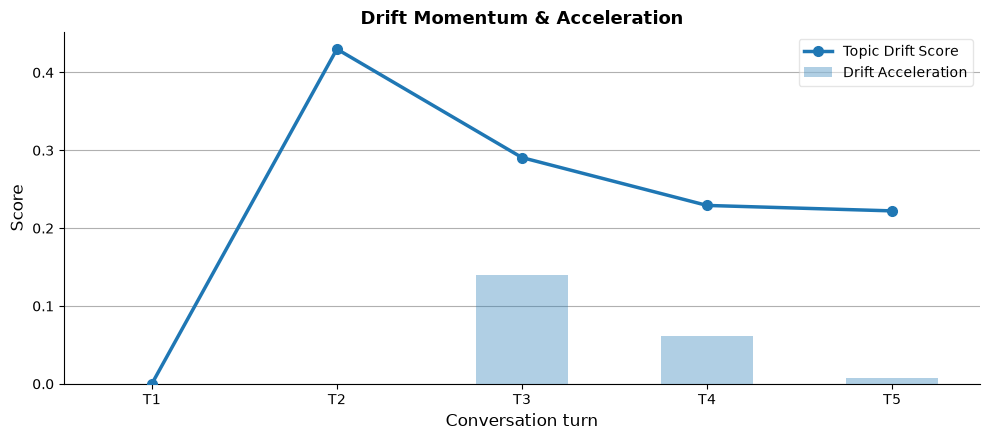

In [3]:
def plot_momentum_accel(sub_df):
    fig, ax = plt.subplots(figsize=(10, 4.5))
    turns = sub_df["turn_id"].values + 1
    drift = sub_df["topic_drift_score"].values
    accel = sub_df["drift_acceleration"].values

    ax.plot(turns, drift, lw=2.5, marker='o', ms=7,
            label='Topic Drift Score', zorder=4)
    ax.bar(turns, accel, alpha=0.35, width=0.5,
           label='Drift Acceleration', zorder=3)

    ax.set_xlabel("Conversation turn", fontsize=12, )
    ax.set_ylabel("Score", fontsize=12, )
    ax.set_title("Drift Momentum & Acceleration", fontsize=13, fontweight='bold', )
    ax.set_xticks(turns)
    ax.set_xticklabels([f"T{t}" for t in turns], )
    ax.yaxis.grid(True, lw=0.8)
    # ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.legend(fontsize=10, framealpha=0.5)
    fig.tight_layout()
   
    plt.show()

plot_momentum_accel(df[df["conv_id"] == 55].sort_values("turn_id").reset_index(drop=True))
plot_momentum_accel(df[df["conv_id"] == 3001].sort_values("turn_id").reset_index(drop=True))


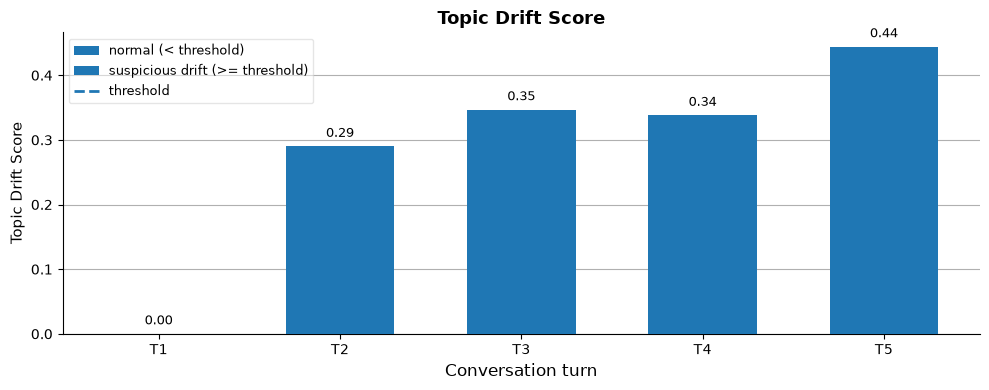

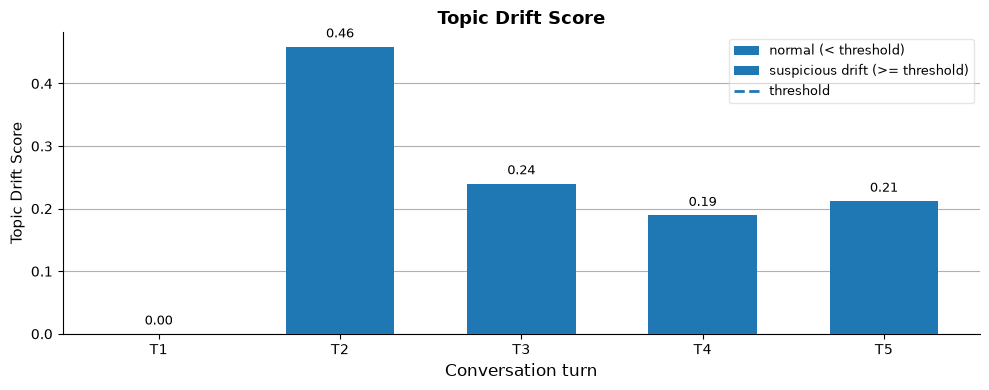

In [4]:
def plot_topic_drift(sub_df):
    fig, ax = plt.subplots(figsize=(10, 4))
    
    turns = sub_df["turn_id"].values + 1 
    drift = sub_df["topic_drift_score"].values
   
    bars = ax.bar(turns, drift, width=0.6, zorder=3)

    ax.set_xlabel("Conversation turn", fontsize=12)
    ax.set_ylabel("Topic Drift Score", fontsize=11)
    ax.set_title("Topic Drift Score", fontsize=13, fontweight='bold')
    ax.set_xticks(turns)
    ax.set_xticklabels([f"T{t}" for t in turns])
    ax.yaxis.grid(True, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
   
    for bar, d in zip(bars, drift):
        ax.text(bar.get_x()+bar.get_width()/2, d+0.01, f"{d:.2f}",
                ha='center', va='bottom', fontsize=9)
    normal_patch = mpatches.Patch( label='normal (< threshold)')
    drift_patch  = mpatches.Patch( label='suspicious drift (>= threshold)')
    ax.legend(handles=[normal_patch, drift_patch,
                       plt.Line2D([0],[0], ls='--', lw=2, label='threshold')],
              fontsize=9, framealpha=0.5)
    fig.tight_layout()

    plt.show()

plot_topic_drift(df[df["conv_id"] == 53].sort_values("turn_id").reset_index(drop=True))
plot_topic_drift(df[df["conv_id"] == 3004].sort_values("turn_id").reset_index(drop=True))


In [5]:
def representative_sim_matrix(mean_sim, std_sim, min_sim, max_sim, n):
   
    rng = np.random.default_rng(42)
    n_pairs = n*(n-1)//2
    vals = rng.normal(loc=mean_sim, scale=max(std_sim, 1e-6), size=n_pairs)
    vals = np.clip(vals, -1, 1)
    # anchor extremes to the real min/max
    vals[np.argmin(vals)] = min_sim
    vals[np.argmax(vals)] = max_sim
    # rescale remaining spread to better match target std while keeping anchors
    mat = np.eye(n)
    k = 0
    idx_pairs = [(i,j) for i in range(n) for j in range(i+1,n)]
    for (i,j), v in zip(idx_pairs, vals):
        mat[i,j] = mat[j,i] = v
    return mat

def draw_heatmap(ax, mat, title, n):
    im = ax.imshow(mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
   
    ax.set_title(title, fontsize=11)
    labels = [f"T{i+1}" for i in range(n)]
    ax.set_xticks(range(n)); ax.set_xticklabels(labels, fontsize=9 )
    ax.set_yticks(range(n)); ax.set_yticklabels(labels, fontsize=9)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha='center', va='center',
                    fontsize=8, color='black' if 0.3 < mat[i,j] < 0.8 else 'white')
    plt.colorbar(im, ax=ax, shrink=0.8, label='similarity')



In [6]:
# beinin conv with conv turn ==6 

df_b= df[df["turn_id"]==6]

In [7]:
df_b

,conv_id,turn_id,label,toxicity_score,threat_score,topic_drift_score,drift_acceleration,origin_drift,drift_momentum,persistent_drift_count,...,threat_diff,toxicity_accel,threat_accel,risk_slope_3,max_toxicity_so_far,max_threat_so_far,mean_risk_so_far,early_high_risk,late_risk_increase,risk_growth_ratio
5412,1219,6,1,0.000117,0.048029,0.2468,0.1084,0.5356,0.2709,6,...,0.038873,0.015681,0.036961,0.030669,0.028942,0.048029,0.049072,0.050593,0.078959,0.560670
5771,1293,6,1,0.000890,0.337116,0.1200,0.1513,0.2297,0.2824,0,...,0.212924,-0.006463,0.192753,0.178191,0.010111,0.367871,0.489859,0.752189,0.388874,-0.483010
7193,1587,6,1,0.005998,0.077583,0.1193,0.0008,0.4771,0.1288,0,...,-0.152141,-0.373019,-0.207636,-0.008075,0.201998,0.229724,0.302486,0.110139,0.556249,4.050386
7555,1663,6,1,0.006847,0.251506,0.1009,0.0315,0.3096,0.1689,0,...,-0.080385,0.003577,0.154992,-0.174638,0.027560,0.743920,0.918103,1.511226,0.786056,-0.479855
7562,1664,6,1,0.001290,0.430813,0.0715,0.1455,0.6927,0.1769,0,...,0.001849,-0.016840,0.242823,-0.368024,0.024811,0.973113,1.135543,1.735602,1.050444,-0.394766
7810,1715,6,1,0.021782,0.511819,0.1416,0.0112,0.3601,0.1209,0,...,0.498578,0.177904,0.490751,0.226864,0.199890,0.511819,0.415470,0.440701,0.599801,0.361015
8145,1783,6,1,0.694980,0.017200,0.0926,0.0401,0.5388,0.1079,0,...,-0.078518,0.547085,-0.103335,0.621375,0.694980,0.155991,0.531255,0.484920,0.915803,0.888566
8181,1790,6,1,0.013284,0.025460,0.0569,0.0276,0.6490,0.1506,0,...,0.014494,-0.119471,0.008251,-0.080799,0.108028,0.303183,0.218228,0.616890,0.118264,-0.808288
9754,2120,6,1,0.007453,0.076311,0.2531,0.0918,0.7121,0.3050,6,...,0.042813,0.015757,0.012516,0.053792,0.030288,0.076311,0.078975,0.108027,0.104680,-0.030977
10540,2276,6,1,0.408167,0.245739,0.2501,0.0296,0.6130,0.2550,6,...,0.238070,-0.672340,0.403481,0.117152,0.866416,0.513548,1.567001,1.636036,2.197655,0.343280


In [8]:
df_attack = df[df["conv_id"]==1790] 
df_normal = df[df["conv_id"]==2800] 

In [9]:
a_row = df_attack.iloc[6]
n_row = df_normal.iloc[6]


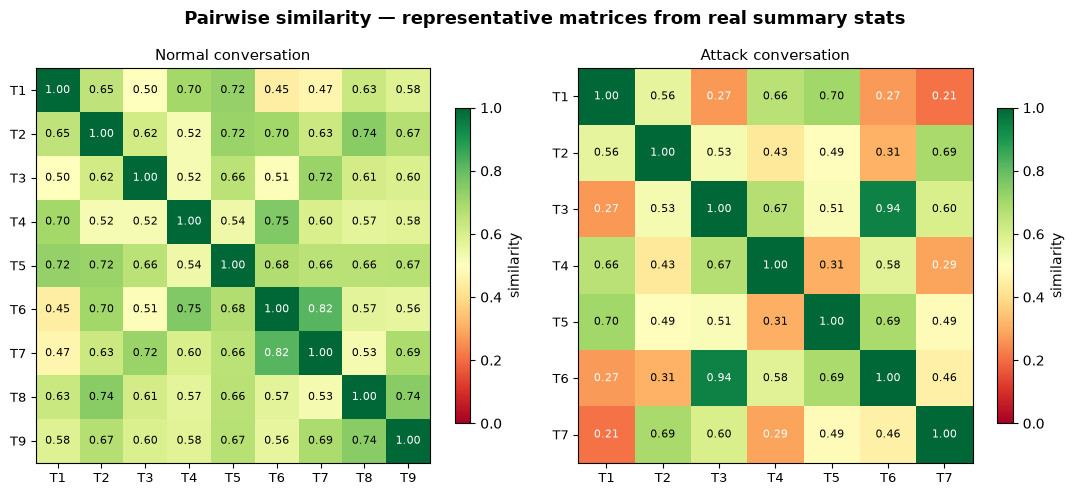

In [10]:

attack_mat = representative_sim_matrix(a_row["mean_similarity"], a_row["std_similarity"],
                                        a_row["min_similarity"], a_row["max_similarity"],  len(df_attack))
normal_mat = representative_sim_matrix(n_row["mean_similarity"], n_row["std_similarity"],
                                        n_row["min_similarity"], n_row["max_similarity"], len(df_normal))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("Pairwise similarity — representative matrices from real summary stats",
             fontsize=13, fontweight='bold')
draw_heatmap(axes[0], normal_mat, "Normal conversation", len(df_normal))
draw_heatmap(axes[1], attack_mat, "Attack conversation", len(df_attack))
for ax in axes:
    ax.spines[:]
fig.tight_layout()
plt.show()
